<a href="https://colab.research.google.com/github/FabriThomas/atividadesAI/blob/main/Previs%C3%A3o_de_qualidade_do_aluno.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

SHEET_ID = "121ZIkLVCJ1KGlOC8k_7ADQ_rBZGYO9SH1PHb7Ig8FhU"
GID = "1047276759"  # aba Página1
url_tsv = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=tsv&gid={GID}"

# TSV + vírgula decimal
df = pd.read_csv(url_tsv, sep="\t", decimal=".")

print("Colunas lidas:", list(df.columns))
display(df)

Colunas lidas: ['student_id', 'age', 'gender', 'academic_level', 'study_hours', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline', 'internet_quality', 'mental_health_score', 'focus_index', 'burnout_level', 'productivity_score', 'exam_score']


,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,20,Other,Undergraduate,3.93,1.42,0.54,2.58,2.62,9.30,...,113,496,0,0,Good,9,35.55,33.24,48.83,22.51
4996,4997,24,Male,High School,4.00,0.00,3.00,4.45,2.47,6.42,...,146,411,0,1,Poor,5,16.87,59.07,23.32,2.00
4997,4998,22,Male,Undergraduate,5.63,2.52,2.89,3.58,1.07,6.65,...,123,306,0,1,Good,7,23.85,47.72,41.09,27.89
4998,4999,17,Male,Undergraduate,3.58,2.83,1.53,5.88,1.28,7.36,...,54,304,1,1,Good,4,13.04,58.90,12.62,3.63


In [ ]:
# 0. Reload fresh data
df = pd.read_csv(url_tsv, sep="\t", decimal=".")

# 1. Define feature groups
NUMERIC_FEATURES = [
    "age", "study_hours", "self_study_hours", "online_classes_hours",
    "sleep_hours", "mental_health_score",
    "focus_index", "burnout_level", "productivity_score",
]
CATEGORICAL_FEATURES = ["gender", "academic_level"]

# 2. Clean numeric features
for col in NUMERIC_FEATURES + ["exam_score"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 3. Handle categorical columns (Encoding)
le = LabelEncoder()
for col in CATEGORICAL_FEATURES:
    df[col] = df[col].astype(str).str.strip().str.lower()
    df[col] = le.fit_transform(df[col])

# 4. Drop NaNs before binning to ensure consistent distribution
df = df.dropna(subset=NUMERIC_FEATURES + CATEGORICAL_FEATURES + ["exam_score"]).copy()

# ---------------------------------------------------------
# BINNING STRATEGY: Uncomment the one you want to use
# ---------------------------------------------------------

# OPTION A: Flat Spread (0-10, 11-20, etc.) - Better for Accuracy due to imbalance
df["exam_score_binned"] = pd.cut(df["exam_score"], bins=10, labels=False)

#OPTION B: % Distribution (Top 10%, Next 10%, etc.) - More "Honest" but harder to predict
#df["exam_score_binned"] = pd.qcut(df["exam_score"], q=5, labels=False, duplicates='drop')

# ---------------------------------------------------------

# 5. Set the Target
TARGET = "exam_score_binned"
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

print(f"Dataset final: {len(df)} linhas")
print(f"Modo: {'Percentil' if 'qcut' in locals() else 'Flat'}")
print("\nDistribuição do Target:")
print(df[TARGET].value_counts().sort_index())

Dataset final: 5000 linhas
Modo: Flat

Distribuição do Target:
exam_score_binned
0    1010
1     835
2     927
3     841
4     685
5     410
6     191
7      76
8      20
9       5
Name: count, dtype: int64


In [ ]:
le = LabelEncoder()
y_all = le.fit_transform(df[TARGET])
X_all = df[FEATURES].values

print("\nClasses:", list(le.classes_))
print("Total linhas válidas:", len(df))


Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Total linhas válidas: 5000


In [ ]:

RANDOM_STATE = 42
df_shuffled = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
limite_teste=int(len(df)*0.20) # Split : 20% teste + 80% treino
test_df  = df_shuffled.iloc[:limite_teste].copy()
train_df = df_shuffled.iloc[limite_teste:len(df)].copy()
X_train = train_df[FEATURES].values
y_train = le.transform(train_df[TARGET])
X_test  = test_df[FEATURES].values
y_test  = le.transform(test_df[TARGET])
print("\nTreino:", len(train_df), "| Teste:", len(test_df))



Treino: 4000 | Teste: 1000


In [ ]:
def dist_classes(frame, target_col, titulo):
    vc = frame[target_col].value_counts(dropna=False)
    pct = (vc / len(frame) * 100).round(1)
    out = pd.DataFrame({"qtd": vc, "%": pct})
    print(f"\n=== {titulo} (n={len(frame)}) ===")
    display(out)

dist_classes(df, TARGET, "Dataset completo")
dist_classes(train_df, TARGET, "Treino")
dist_classes(test_df, TARGET, "Teste")


=== Dataset completo (n=5000) ===


,qtd,%
exam_score_binned,,
0,1010,20.2
2,927,18.5
3,841,16.8
1,835,16.7
4,685,13.7
5,410,8.2
6,191,3.8
7,76,1.5
8,20,0.4



=== Treino (n=4000) ===


,qtd,%
exam_score_binned,,
0,806,20.2
2,747,18.7
3,675,16.9
1,664,16.6
4,525,13.1
5,335,8.4
6,157,3.9
7,67,1.7
8,20,0.5



=== Teste (n=1000) ===


,qtd,%
exam_score_binned,,
0,204,20.4
2,180,18.0
1,171,17.1
3,166,16.6
4,160,16.0
5,75,7.5
6,34,3.4
7,9,0.9
9,1,0.1


In [ ]:
# Modelo KNN
K = 13
WEIGHTS = "distance"  # "uniform" ou "distance"

model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=K, weights=WEIGHTS))
])

model.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('knn',
                 KNeighborsClassifier(n_neighbors=13, weights='distance'))])

In [ ]:
# Avaliação

y_pred = model.predict(X_test)

print("\nFeatures usadas:", FEATURES)
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório:")
print(classification_report(y_test, y_pred, labels=le.classes_, target_names=[str(c) for c in le.classes_]))
print("Matriz de confusão (real x previsto):")
print(confusion_matrix(y_test, y_pred))



Features usadas: ['age', 'study_hours', 'self_study_hours', 'online_classes_hours', 'sleep_hours', 'mental_health_score', 'focus_index', 'burnout_level', 'productivity_score', 'gender', 'academic_level']
Acurácia: 0.439

Relatório:
              precision    recall  f1-score   support

           0       0.68      0.71      0.69       204
           1       0.46      0.36      0.40       171
           2       0.36      0.39      0.37       180
           3       0.31      0.39      0.35       166
           4       0.42      0.40      0.41       160
           5       0.35      0.37      0.36        75
           6       0.42      0.15      0.22        34
           7       0.00      0.00      0.00         9
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         1

    accuracy                           0.44      1000
   macro avg       0.30      0.28      0.28      1000
weighted avg       0.44      0.44      0.44      1000

Matriz d

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [ ]:
# Resultado detalhado do teste
test_df["classe_prevista"] = le.inverse_transform(y_pred)
display(test_df[["exam_score"] + FEATURES + [TARGET, "classe_prevista"]])

,exam_score,age,study_hours,self_study_hours,online_classes_hours,sleep_hours,mental_health_score,focus_index,burnout_level,productivity_score,gender,academic_level,exam_score_binned,classe_prevista
0,27.21,21,1.69,1.27,2.03,7.76,10,33.02,34.29,49.20,0,1,4,4
1,4.22,22,5.83,1.85,1.52,6.89,6,30.61,76.88,32.73,2,0,0,1
2,12.14,23,2.97,0.67,2.80,5.00,7,34.04,60.70,34.98,0,0,1,2
3,32.94,20,5.06,1.40,2.57,7.57,10,30.69,49.63,61.26,1,0,5,4
4,22.28,19,4.36,2.25,1.19,6.49,6,32.55,40.06,33.99,0,2,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,22.75,23,5.58,2.58,1.56,8.01,7,34.34,63.85,48.35,1,2,3,4
996,20.66,24,4.51,4.56,4.21,7.05,5,34.82,49.19,38.50,2,2,3,2
997,33.85,17,5.73,1.03,2.08,8.15,7,42.98,30.16,66.56,2,1,5,5
998,27.35,21,4.91,1.87,2.53,5.49,9,44.49,52.79,54.11,0,0,4,4



=== Árvore de decisão ===
Features usadas: ['age', 'study_hours', 'self_study_hours', 'online_classes_hours', 'sleep_hours', 'mental_health_score', 'focus_index', 'burnout_level', 'productivity_score', 'gender', 'academic_level']
Acurácia: 0.452

Relatório:
              precision    recall  f1-score   support

           0       0.66      0.82      0.73       204
           1       0.00      0.00      0.00       171
           2       0.36      0.56      0.43       180
           3       0.39      0.45      0.42       166
           4       0.42      0.54      0.48       160
           5       0.33      0.31      0.32        75
           6       0.00      0.00      0.00        34
           7       0.00      0.00      0.00         9
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         1

    accuracy                           0.45      1000
   macro avg       0.22      0.27      0.24      1000
weighted avg       0.36      0.45    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

,exam_score,age,study_hours,self_study_hours,online_classes_hours,sleep_hours,mental_health_score,focus_index,burnout_level,productivity_score,gender,academic_level,exam_score_binned,classe_prevista_arvore
0,27.21,21,1.69,1.27,2.03,7.76,10,33.02,34.29,49.20,0,1,4,4
1,4.22,22,5.83,1.85,1.52,6.89,6,30.61,76.88,32.73,2,0,0,2
2,12.14,23,2.97,0.67,2.80,5.00,7,34.04,60.70,34.98,0,0,1,2
3,32.94,20,5.06,1.40,2.57,7.57,10,30.69,49.63,61.26,1,0,5,5
4,22.28,19,4.36,2.25,1.19,6.49,6,32.55,40.06,33.99,0,2,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,22.75,23,5.58,2.58,1.56,8.01,7,34.34,63.85,48.35,1,2,3,4
996,20.66,24,4.51,4.56,4.21,7.05,5,34.82,49.19,38.50,2,2,3,3
997,33.85,17,5.73,1.03,2.08,8.15,7,42.98,30.16,66.56,2,1,5,5
998,27.35,21,4.91,1.87,2.53,5.49,9,44.49,52.79,54.11,0,0,4,4


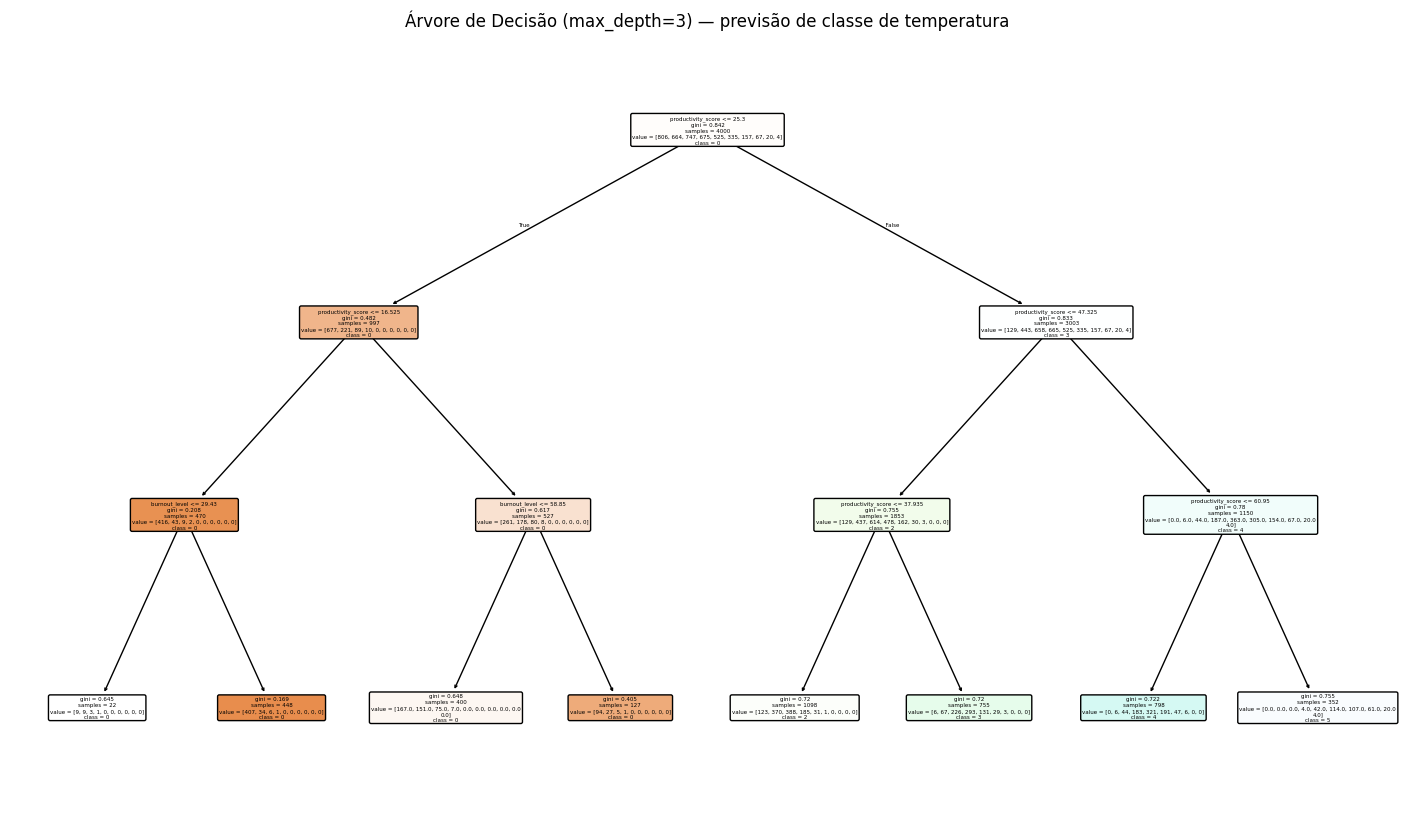

In [ ]:
# ========= Árvore de decisão (usando as MESMAS variáveis do seu Colab) =========
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# "simples" e legível para aula (ajuste se quiser):
tree = DecisionTreeClassifier(
    max_depth=3,          # controla complexidade/legibilidade
    random_state=RANDOM_STATE
)

tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("\n=== Árvore de decisão ===")
print("Features usadas:", FEATURES)
print("Acurácia:", accuracy_score(y_test, y_pred_tree))
print("\nRelatório:")
print(classification_report(y_test, y_pred_tree, labels=le.classes_, target_names=[str(c) for c in le.classes_]))
print("Matriz de confusão (real x previsto):")
print(confusion_matrix(y_test, y_pred_tree))

# Resultado detalhado do teste (sem mudar sua tabela do KNN, usa outra coluna)
test_df["classe_prevista_arvore"] = le.inverse_transform(y_pred_tree)
display(test_df[["exam_score"] + FEATURES + [TARGET, "classe_prevista_arvore"]])

# desenhar a árvore
plt.figure(figsize=(18, 10))
plot_tree(
    tree,
    feature_names=FEATURES,
    class_names=[str(c) for c in le.classes_], # Convert class names to strings
    filled=True,
    rounded=True,
    impurity=True
)
plt.title("Árvore de Decisão (max_depth=3) — previsão de classe de temperatura")
plt.show()
